In [15]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier
from matplotlib.colors import ListedColormap
from sklearn.datasets import make_moons
from sklearn.ensemble import BaggingClassifier
import pandas as pd

<p dir=rtl style="direction: rtl;text-align: justify;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
در این تمرین، ما قصد داریم تأثیر پارامترهای هایپر در مدل درخت تصمیم را بررسی کنیم و سپس به مقایسه و بررسی مدل‌های درخت تصمیم و یادگیری انبوه (Ensemble Learning) بپردازیم.



<p dir=rtl style="direction: rtl;text-align: justify;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
در ابتدابه بررسی هایپر پارامتر max_depth می‌پردازیم

<p dir=rtl style="direction: rtl;text-align: justify;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
دیتاست Iris یکی از مجموعه‌داده‌های معروف در علم داده است که معمولاً برای مسائل آموزشی  استفاده می‌شود. این دیتاست اطلاعاتی در مورد گل‌های زنبق را در اختیار ما قرار می‌دهد. این دیتاست شامل مشخصات سه گونه مختلف از گل‌های زنبق است:
<ul dir=rtl>
<li dir=rtl style="direction: rtl;text-align: justify;line-height:200%;font-family:vazir;font-size:medium">
Iris setosa
<li dir=rtl style="direction: rtl;text-align: justify;line-height:200%;font-family:vazir;font-size:medium">
Iris virginica
<li dir=rtl style="direction: rtl;text-align: justify;line-height:200%;font-family:vazir;font-size:medium">
Iris versicolor
</ul>
<p dir=rtl style="direction: rtl;text-align: justify;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
هر نمونه از این دیتاست شامل چهار ویژگی است:
<ul dir=rtl>
<li dir=rtl style="direction: rtl;text-align: justify;line-height:200%;font-family:vazir;font-size:medium">
طول کاسبرگ (Sepal Length)
<li dir=rtl style="direction: rtl;text-align: justify;line-height:200%;font-family:vazir;font-size:medium">
عرض کاسبرگ (Sepal Width)
<li dir=rtl style="direction: rtl;text-align: justify;line-height:200%;font-family:vazir;font-size:medium">
 طول گلبرگ (Petal Length)
<li dir=rtl style="direction: rtl;text-align: justify;line-height:200%;font-family:vazir;font-size:medium">
عرض گلبرگ (Petal Width)
</ul>
<p dir=rtl style="direction: rtl;text-align: justify;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
این ویژگی‌ها به واحد سانتی‌متر اندازه‌گیری شده‌اند. اهمیت این دیتاست از آنجاست که ساختار ساده‌ای دارد و معمولاً به عنوان یک مسئله‌ی معمولی در مسائل آموزشی مورد استفاده قرار می‌گیرد.

<p dir=rtl style="direction: rtl;text-align: justify;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
فرض کنید که شما با استفاده از درخت تصمیم قصد دارید داده‌های آموزشی مربوط به دسته‌بندی گل‌های زنبق را کلاس‌بندی کنید. از دو ویژگی پتال (طول و عرض) برای این کار استفاده می‌کنید. شما دو مدل درخت تصمیم را با اعماق مختلف می‌سازید: یک مدل با `max_depth=2` و`max_depth=3`و`max_depth=5`و`max_depth=10`.
<p dir=rtl style="direction: rtl;text-align: justify;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
با استفاده از تابع plot_decision_boundary چگونگی دسته بندی داده ها را رسم نمایید و سپس توضیح دهید که چگونه اعماق مختلف می‌تواند ساختار درخت تصمیم را تحت تأثیر قرار دهد و تاثیر عمق بر overfit و underfit  را توضیح دهید.




In [16]:
# I have changed the function in an attemp to model the different cases.
def plot_decision_boundary(clf, X, y, X_column, Y_column, givenPlot, axes=[0, 7.5, 0, 3], iris=True, legend=False, plot_training=True):
    x1s = np.linspace(axes[0], axes[1], 100)
    x2s = np.linspace(axes[2], axes[3], 100)
    x1, x2 = np.meshgrid(x1s, x2s)
    X_new = np.c_[x1.ravel(), x2.ravel()]
    y_pred = clf.predict(X_new).reshape(x1.shape)
    custom_cmap = ListedColormap(['#fafab0','#9898ff','#a0faa0'])
    givenPlot.contourf(x1, x2, y_pred, alpha=0.3, cmap=custom_cmap)
    if plot_training:
        givenPlot.plot(X[:, 0][y==0], X[:, 1][y==0], "yo", label="Iris-Setosa")
        givenPlot.plot(X[:, 0][y==1], X[:, 1][y==1], "bs", label="Iris-Versicolor")
        givenPlot.plot(X[:, 0][y==2], X[:, 1][y==2], "g^", label="Iris-Virginica")
        givenPlot.axis(axes)
    if iris:
        givenPlot.set_xlabel(X_column, fontsize=14)
        givenPlot.set_ylabel(Y_column, fontsize=14)
    else:
        givenPlot.set_xlabel(r"$x_1$", fontsize=18)
        givenPlot.set_ylabel(r"$x_2$", fontsize=18, rotation=0)
    if legend:
        plt.legend(loc="lower right", fontsize=14)

    givenPlot.spines["top"].set_visible(False)
    givenPlot.spines["right"].set_visible(False)
    givenPlot.spines["left"].set_visible(False)

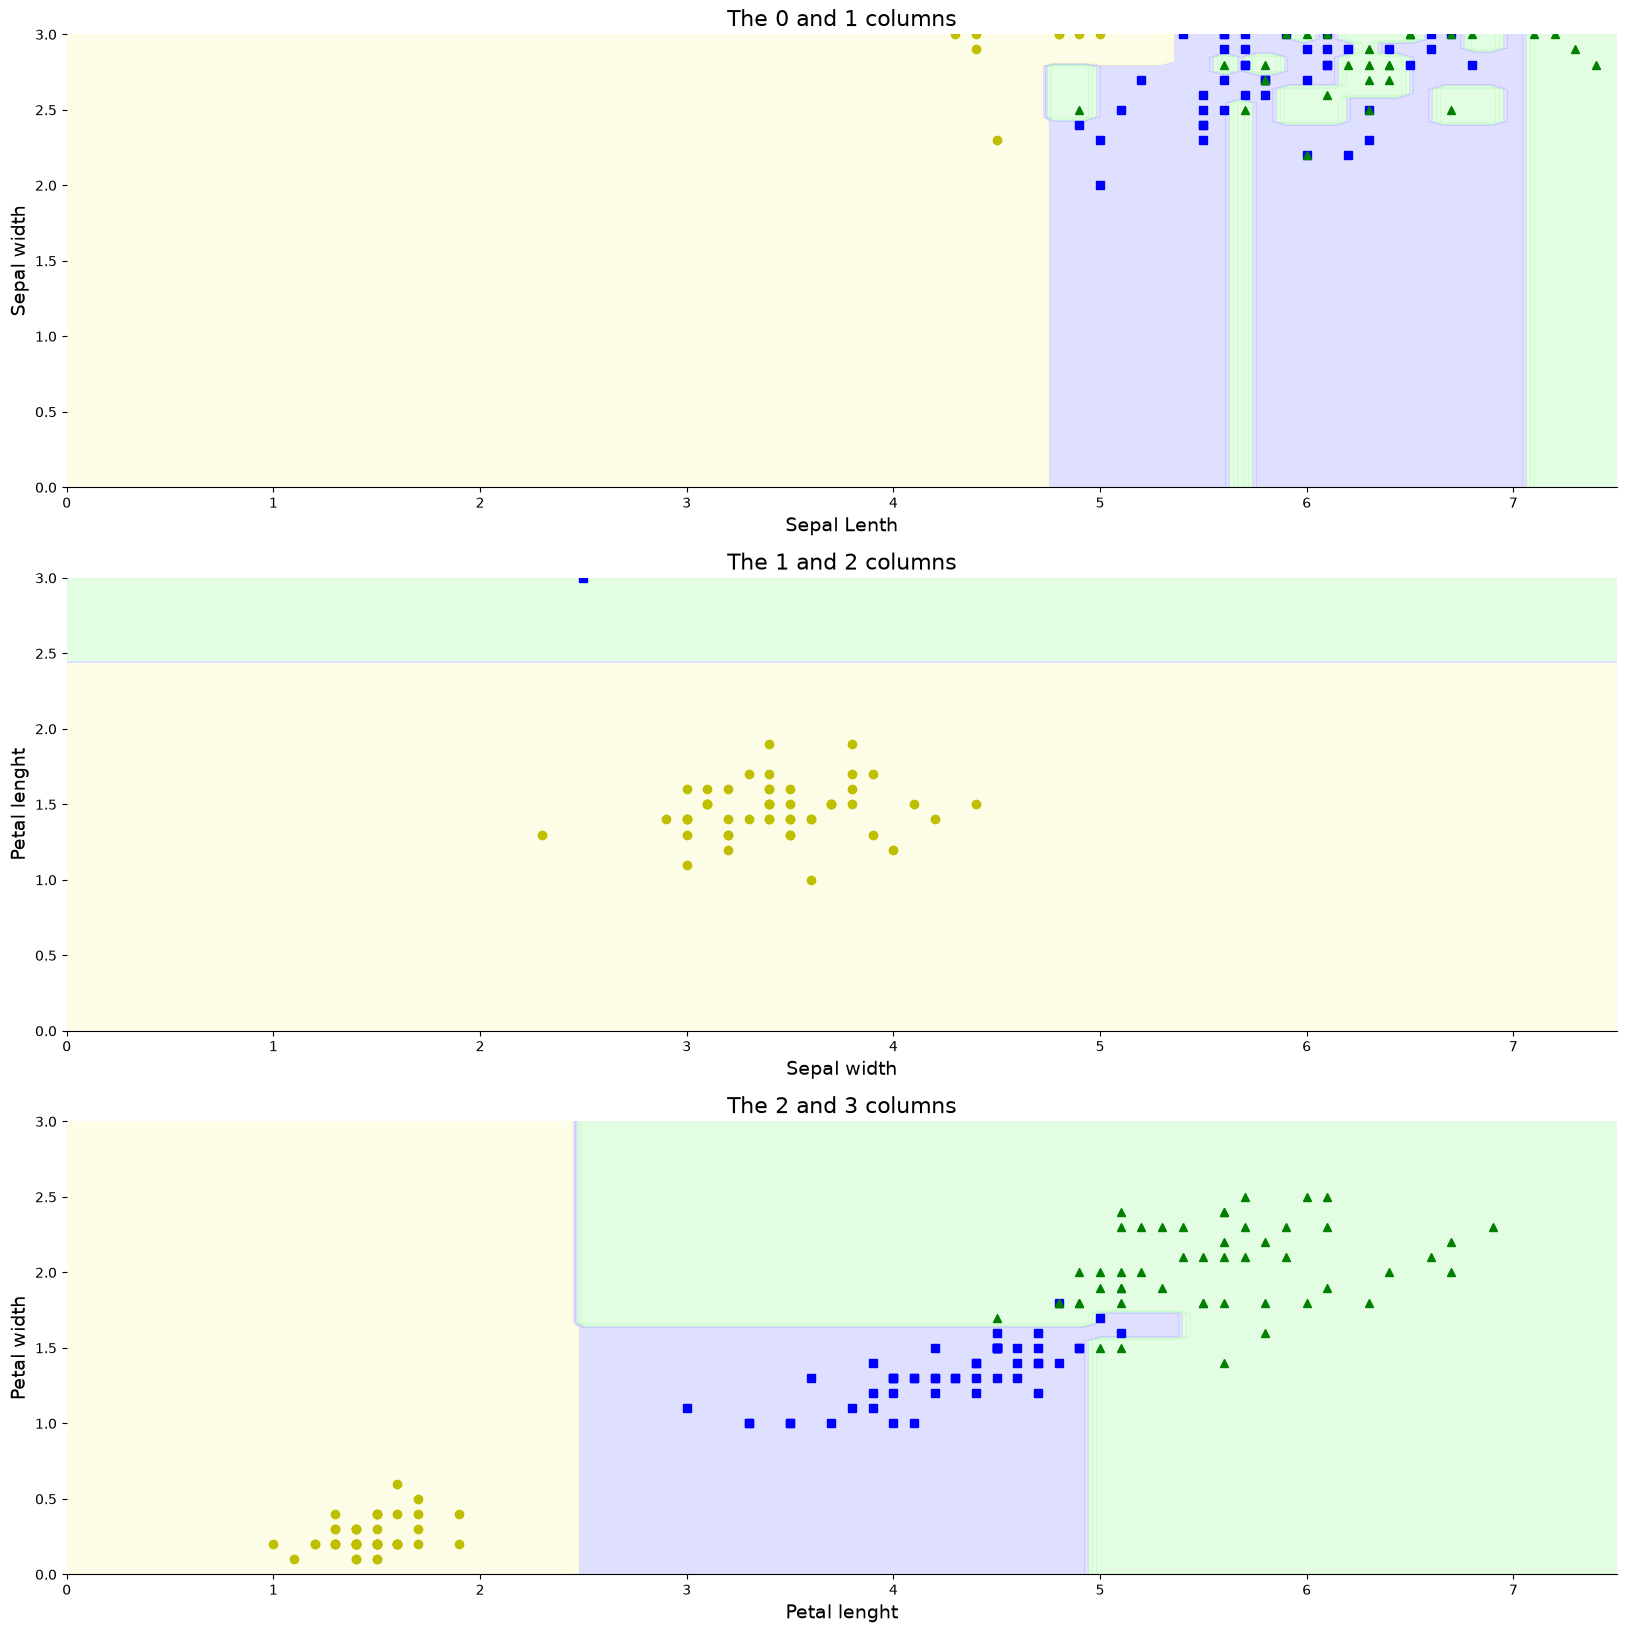

In [17]:
# load iris dataset
from sklearn.tree import DecisionTreeClassifier
columns = ["Sepal Lenth", "Sepal width", "Petal lenght", "Petal width"]

train_x, train_y = load_iris(return_X_y=True)
# The function requires to have 2 feature fot he model.
# for intance we assume have the 2 and 3 column.
figure, axes = plt.subplots(3, 1, figsize=(20, 20))
for i in range(3):
    train_changed_x = train_x[:, i:i+2]
    model = DecisionTreeClassifier()
    model.fit(train_changed_x, train_y)

    axes[i].set_title(f"The {i} and {i+1} columns", fontsize=16)
    plot_decision_boundary(model, train_changed_x, train_y, columns[i], columns[i+1], givenPlot=axes[i])


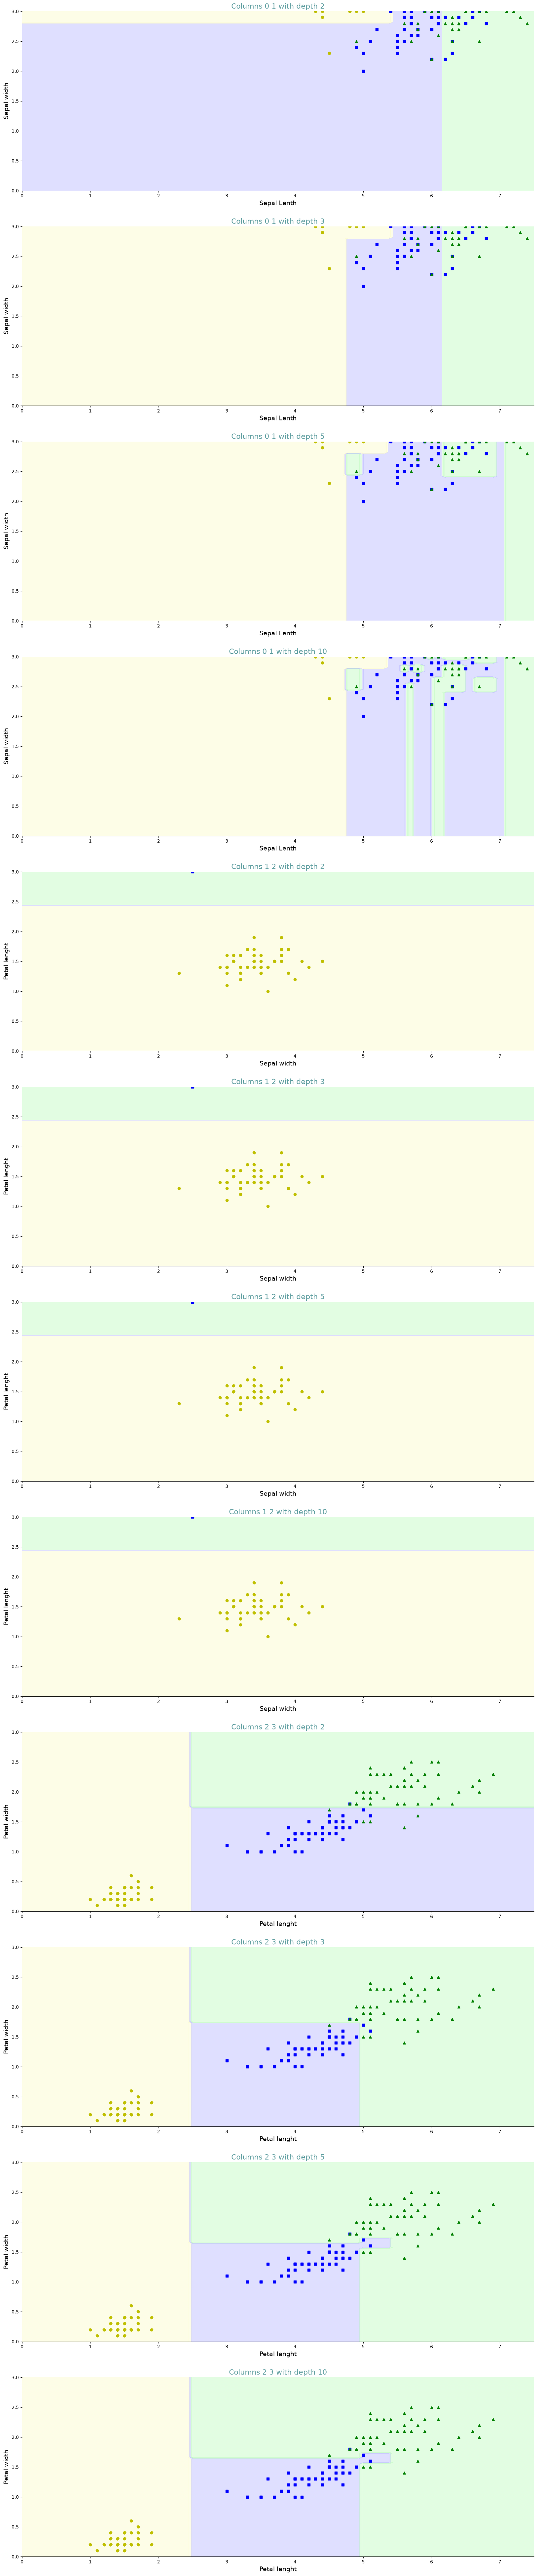

In [18]:
# train DecisionTreeClassifier with [2, 3, 5, 10] max_depth
axes_number = 0
figure, axes = plt.subplots(12, 1, figsize=(20, 100))
depth_candidates = [2, 3, 5, 10]
for i in range(3):
    for depth in depth_candidates:
        train_changed_x = train_x[:, i:i+2]
        train_changed_y = train_y
        model = DecisionTreeClassifier(max_depth=depth)
        model.fit(train_changed_x, train_y)

        axes[axes_number].set_title(f"Columns {i} {i+1} with depth {depth}", fontsize=16, color="cadetblue")
        plot_decision_boundary(model, train_changed_x, train_changed_y, columns[i], columns[i+1], givenPlot=axes[axes_number])
        axes_number += 1


In [19]:
# The explanation of the decision tree depth:
# if the depth is to high the model will not learn the patterns of the data instead it learn the bias and every example(memorize the data)
# which causes in overfitting in the other hand the low depth with cause the underfitting beacuase the model can not fit the pattren
# of the data.

<p dir=rtl style="direction: rtl;text-align: justify;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
در قسمت بعد می‌خواهیم تأثیر پارامتر min_samples_leaf در مدل درخت تصمیم را بررسی کنیم. این پارامتر نشان دهنده حداقل تعداد نمونه‌هایی است که باید در یک برگ درخت وجود داشته باشد.
<p dir=rtl style="direction: rtl;text-align: justify;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
برای بررسی تاثیر این هایپر پارامتر از تابع make_moon استفاده میکنیم و به صورت رندم داده‌هایی را تولید می‌کنیم. سپس با مقادیر مختلف min_samples_leaf =  [1, 10, 20] و داده‌های تولید شده از make_moon تاثیر آن را بر دسته بندی درخت تصمیم را بررسی می‌کنیم.
مانند قسمت قبل با استفاده از تابع plot_decision_boundary چگونگی دسته بندی داده‌ها را رسم نمایید و سپس تاثیر این هایپر پارامتر را توضیح دهید.

In [20]:
X, y = make_moons(n_samples=300, noise=0.3, random_state=42)

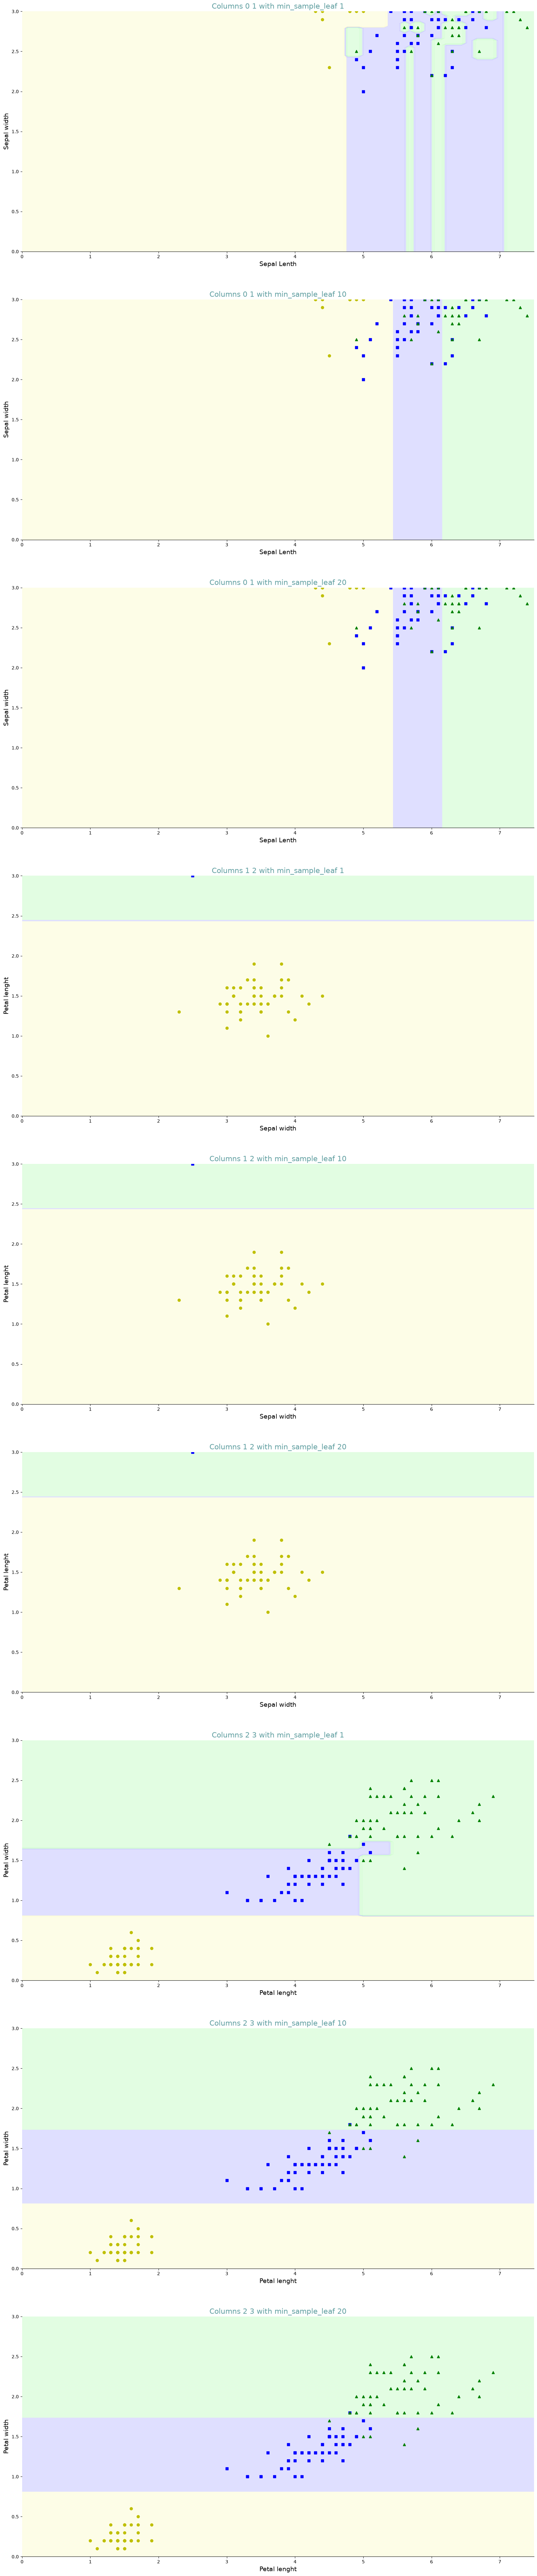

In [21]:
# train DecisionTreeClassifier with [1, 10, 20] min_samples_leaf
min_sample_leaf_list = [1, 10, 20]
axes_number = 0
figure, axes = plt.subplots(9, 1, figsize=(20, 100))
for i in range(3):
    for min_sample_leaf in min_sample_leaf_list:
        train_changed_x = train_x[:, i:i+2]
        train_changed_y = train_y
        model = DecisionTreeClassifier(min_samples_leaf=min_sample_leaf)
        model.fit(train_changed_x, train_y)

        axes[axes_number].set_title(f"Columns {i} {i+1} with min_sample_leaf {min_sample_leaf}", fontsize=16, color="cadetblue")
        plot_decision_boundary(model, train_changed_x, train_changed_y, columns[i], columns[i+1], givenPlot=axes[axes_number])
        axes_number += 1


# The result shows the the loew mins_sample_leaf cause overfiiting due to the effort of the model to seperate the data to reach that leaf
# so the model will not llearn the genral pattern instead it will memorize the data.
# in the other hand if the sample is too high the model may underfit beacause of the less seperation in the nodes and the leafs have
# much more than sample with less purity.

<p dir=rtl style="direction: rtl;text-align: justify;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
در قسمت بعد می‌خواهیم متد Bagging  را با درخت تصمیم با اعماق مختلف مقایسه کنیم.از همان دیتا ست make_moon  استفاده می‌کنیم. درخت های تصمیم با عمق [1, 2, 3, 5, 10] را آموزش دهید و پلات آن‌ها را نیز رسم نمایید.
 سپس از bagging استفاده می‌کنیم. تخمین‌گر bagging  را آخرین درخت قرار دهید
  ، تعداد تخمین‌گر‌ها در سپس متد bagging را برابر 500 عدد قرار دهید و ماکزیمم سمپل را نیز 100 قرار دهید سپس با استفاده از تابع plot_decision_boundary چگونگی دسته بندی داده‌ها را رسم نمایید.  


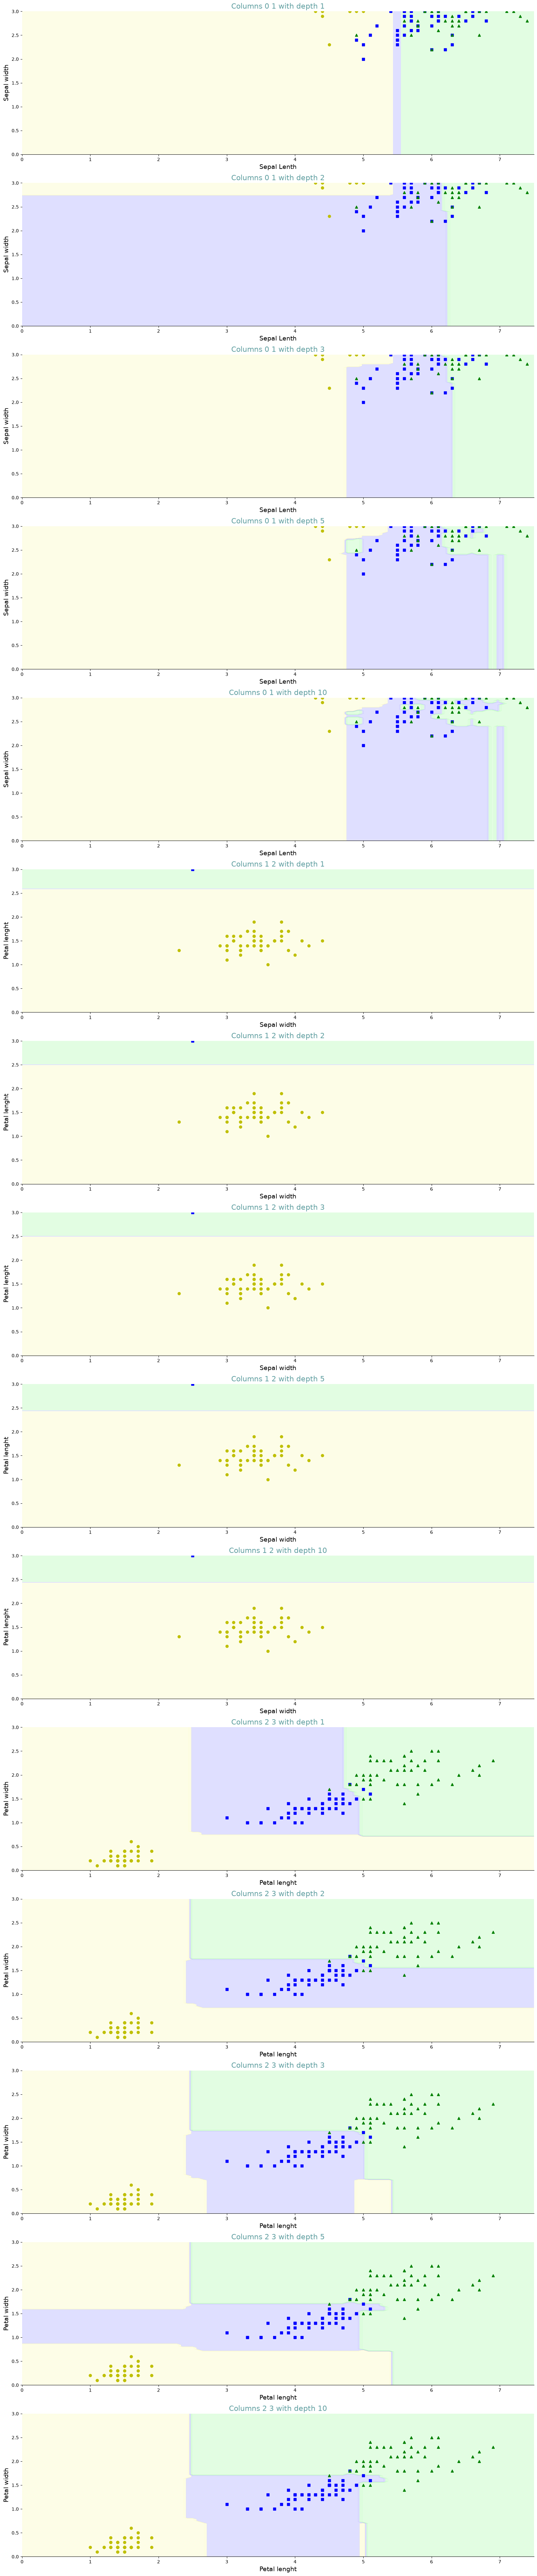

In [22]:
# train DecisionTreeClassifier with [2, 3, 5, 10] max_depth and BaggingClassifier
from sklearn.ensemble import  BaggingClassifier
from sklearn.tree import  DecisionTreeClassifier

axes_number = 0
figure, axes = plt.subplots(15, 1, figsize=(20, 100))
depth_candidates = [1, 2, 3, 5, 10]
for i in range(3):
    for depth in depth_candidates:
        train_changed_x = train_x[:, i:i+2]
        train_changed_y = train_y

        model = DecisionTreeClassifier(max_depth=depth)        
        bagging_model = BaggingClassifier(estimator=model, max_samples=100, n_estimators=500)
        bagging_model.fit(train_changed_x, train_changed_y)

        axes[axes_number].set_title(f"Columns {i} {i+1} with depth {depth}", fontsize=16, color="cadetblue")
        plot_decision_boundary(bagging_model, train_changed_x, train_changed_y, columns[i], columns[i+1], givenPlot=axes[axes_number])
        axes_number += 1

<p dir=rtl style="direction: rtl;text-align: justify;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
فراموش نکنید که اگرچه که می‌توانیم هایپر پارامترها را سرچ کنیم(مثلا با متد گرید سرچ)اما بهتر است که شهودی از تاثیر آن‌ها بر مدل را داشته باشیم، زیرا درک تاثیر هایپرپارامترها و تاثیر آن‌ها روی یکدیگر به اضافه درک درست از داده‌ها می‌تواند فضای سرچ را کوچک کند در نتیجه هزینه آموزش مدل کاهش میابد.

<h2 align=right style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir" color="#0099cc">
بهینه‌سازی بیزی برای تنظیم ابرپارامترها
<p dir=rtl style="direction: rtl;text-align: justify;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
بهینه‌سازی بیزی یک روش کارآمد برای تنظیم ابرپارامترها است. برخلاف جستجوی شبکه‌ای و جستجوی تصادفی که بیشتر به صورت جستجوی بی‌رحمانه عمل می‌کنند، بهینه‌سازی بیزی مدل احتمالاتی از تابع هدف ایجاد می‌کند و از آن برای انتخاب امیدوارکننده‌ترین ابرپارامترها برای ارزیابی استفاده می‌کند.
<p dir=rtl style="direction: rtl;text-align: justify;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
در این بخش، از کتابخانه `scikit-optimize` برای انجام بهینه‌سازی بیزی بر روی یک مدل درخت تصمیم استفاده خواهیم کرد.

</font>
</p>



<p dir=rtl style="direction: rtl;text-align: justify;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
در این بخش، تابعی برای بهینه‌سازی تعریف می‌کنیم که هایپرپارامترها را به عنوان ورودی دریافت می‌کند، مدل درخت تصمیم را با این پارامترها آموزش می‌دهد و میانگین امتیاز اعتبارسنجی متقابل را برمی‌گرداند.
<p dir=rtl style="direction: rtl;text-align: justify;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
در نتیجه یک فضای پارامتری دل خواه برای هایپرپارامتر های max_depth,
min_samples_split,
min_samples_leaf
ایجاد کنید و با استفاده از سه متد
<ul dir=rtl>
<li dir=rtl style="direction: rtl;text-align: justify;line-height:200%;font-family:vazir;font-size:medium">
BayesSearchCV
<li dir=rtl style="direction: rtl;text-align: justify;line-height:200%;font-family:vazir;font-size:medium">
GridSearchCV
<li dir=rtl style="direction: rtl;text-align: justify;line-height:200%;font-family:vazir;font-size:medium">
RandomizedSearchCV
</ul>
<p dir=rtl style="direction: rtl;text-align: justify;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
بهترین مقادیر هایپرپارمتر ها را بیابید و در انتها هر کدام از نتایج رااز لحاظ عملکرد و کارآیی محاسباتی تحلیل کنید
</font>
</p>

In [23]:
#!pip install scikit-optimize

<p dir=rtl style="direction: rtl;text-align: justify;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
برای آشنایی با کتابخانه scikit-optimize می توانید به <a href="https://pypi.org/project/scikit-optimize/">اینجا</a> و <a href="https://scikit-optimize.github.io/stable/install.html">اینجا</a> مراجعه کنید.

In [ ]:
from skopt import BayesSearchCV
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, StratifiedKFold

distribution_dict: dict = {
    "min_samples_split" : [2, 5, 10],
    "min_samples_leaf" : [5, 10 , 20],
    "max_depth" : [1, 2, 5, 10]
}

scores: dict  = {}
cv_result: dict = {}
def tune_best_hypreparamter():
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    decision_tree = DecisionTreeClassifier(random_state=42)


    grid_search = GridSearchCV(estimator=decision_tree, param_grid=distribution_dict
        , cv=cv, n_jobs=-1)
    random_search = RandomizedSearchCV(estimator=decision_tree, random_state=42
        ,param_distributions=distribution_dict, n_jobs=-1, cv=cv)
    byse_search = BayesSearchCV(estimator=decision_tree, search_spaces=distribution_dict
        , random_state=42, n_jobs=-1, cv=cv)
    
    grid_search.fit(train_changed_x, train_changed_y)
    scores["grid_search"] = grid_search.best_score_
    cv_result["grid_search"] = grid_search.cv_results_['mean_test_score']

    print(f"grid_search best paramters : ")
    print(grid_search.best_params_)

    random_search.fit(train_changed_x, train_changed_y)
    scores["random_search"] = random_search.best_score_
    cv_result["random_search"] = random_search.cv_results_['mean_test_score']

    print(f"random_search best paramters : ")
    print(random_search.best_params_)

    byse_search.fit(train_changed_x, train_changed_y)
    scores["byse_search"] = byse_search.best_score_
    cv_result["byse_search"] = byse_search.cv_results_['mean_test_score']


    print(f"byse_search best paramters : ")
    print(byse_search.best_params_)

tune_best_hypreparamter()

print("----------------------")

print("Scores : ")
print(scores)

print("----------------------")

print("Cv results : ")
print(cv_result)

# The scores are almost same which means the Search with differenr parameters value gives us samoe score. 
# This could also mean they are making similiar or same trees.

grid_search best paramters : 
{'max_depth': 2, 'min_samples_leaf': 5, 'min_samples_split': 2}
random_search best paramters : 
{'min_samples_split': 10, 'min_samples_leaf': 20, 'max_depth': 10}


/home/amirreza-s-nasiri/Documents/Programming/Artificial-Inteligance-Boot-Camp/venv/lib/python3.12/site-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [np.int64(5), np.int64(5), np.int64(10)] before, using random point [5, 10, 10]
  warnings.warn(
/home/amirreza-s-nasiri/Documents/Programming/Artificial-Inteligance-Boot-Camp/venv/lib/python3.12/site-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [np.int64(2), np.int64(10), np.int64(10)] before, using random point [1, 10, 10]
  warnings.warn(
/home/amirreza-s-nasiri/Documents/Programming/Artificial-Inteligance-Boot-Camp/venv/lib/python3.12/site-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [np.int64(5), np.int64(5), np.int64(10)] before, using random point [2, 10, 5]
  warnings.warn(
/home/amirreza-s-nasiri/Documents/Programming/Artificial-Inteligance-Boot-Camp/venv/lib/python3.12/site

byse_search best paramters : 
OrderedDict({'max_depth': 2, 'min_samples_leaf': 20, 'min_samples_split': 10})
----------------------
Scores : 
{'grid_search': np.float64(0.9400000000000001), 'random_search': np.float64(0.9400000000000001), 'byse_search': np.float64(0.9400000000000001)}
----------------------
Cv results : 
{'grid_search': array([0.66666667, 0.66666667, 0.66666667, 0.66666667, 0.66666667,
       0.66666667, 0.66666667, 0.66666667, 0.66666667, 0.94      ,
       0.94      , 0.94      , 0.94      , 0.94      , 0.94      ,
       0.94      , 0.94      , 0.94      , 0.94      , 0.94      ,
       0.94      , 0.94      , 0.94      , 0.94      , 0.94      ,
       0.94      , 0.94      , 0.94      , 0.94      , 0.94      ,
       0.94      , 0.94      , 0.94      , 0.94      , 0.94      ,
       0.94      ]), 'random_search': array([0.94      , 0.94      , 0.94      , 0.94      , 0.94      ,
       0.94      , 0.94      , 0.94      , 0.66666667, 0.94      ]), 'byse_search': arr

<h2 align=right style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir" color="#0099cc">
<b>سلول جواب‌ساز</b>
</font>
</h2>

<p dir=rtl style="direction: rtl; text-align: justify; line-height:200%; font-family:vazir; font-size:medium">
<font face="vazir" size=3>
    برای ساخته‌شدن فایل <code>result.zip</code> سلول زیر را اجرا کنید. توجه داشته باشید که پیش از اجرای سلول زیر تغییرات اعمال شده در نت‌بوک را ذخیره کرده باشید (<code>ctrl+s</code>) تا در صورت نیاز به پشتیبانی امکان بررسی کد شما وجود داشته باشد.
</font>
</p>

In [1]:
import zipfile
import joblib

def compress(file_names):
    print("File Paths:")
    print(file_names)
    compression = zipfile.ZIP_DEFLATED
    with zipfile.ZipFile("result.zip", mode="w") as zf:
        for file_name in file_names:
            zf.write('./' + file_name, file_name, compress_type=compression)


file_names = ['Decision_Trees.ipynb']
compress(file_names)

File Paths:
['Decision_Trees.ipynb']
